# Importation des libraries

In [20]:
import rds2py
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pds
#import libraries
import scanpy as sc
import cell2location as c2l
import squidpy as sq


# Pancreas :  HT224P1

In [21]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

#lire les données 
pan224_sc = sc.read("data/data_h5ad/HT224P1-S1.h5ad") # mettre le nom du fichier scRNAseq



pan224_st = sc.read("data/data_h5ad/HT224P1-S1Fc2U1Z1Bs1-SeuratObj.h5ad") # mettre le nom du fichier spatial
pan224_st.obsm['spatial'] = pan224_st.obsm["X_spatial"]
#Traitement de données spatial
sc.pp.normalize_total(pan224_st)
sc.pp.log1p(pan224_st)
sc.pp.pca(pan224_st,n_comps=10)
sc.pp.neighbors(pan224_st)
sc.tl.leiden(pan224_st)
sc.tl.umap(pan224_st)

print(pan224_sc)
print(pan224_st)

normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=10
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 10
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    finished: found 14 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)
AnnData object with n_obs × n_vars = 2798 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Piece_ID', 'cell_type', 'Original_barcode'
    var: 'features'
AnnData object with n_obs × n_vars = 2295 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'percent_mt', 'percent_rb', 'percent_hb',

In [22]:
print("before HVG : ", pan224_sc.shape)
sc.pp.highly_variable_genes(
    pan224_sc,
    n_top_genes=2000,
    subset=False,
    flavor='seurat_v3'
)
print("after HVG : ", pan224_sc.shape)

before HVG :  (2798, 36601)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
after HVG :  (2798, 36601)


In [23]:
pan224_sc.layers["counts"] = pan224_sc.X.copy()

In [24]:
pan224_sc.obs

,nCount_RNA,nFeature_RNA,percent.mito,nCount_SCT,nFeature_SCT,seurat_clusters,Piece_ID,cell_type,Original_barcode
PDAC_HT224P1-S1_AAACAGCCAGTAATAG-1,1243.0,867,0.804505,2424.0,872,1,HT224P1-S1,T-cells,AAACAGCCAGTAATAG-1
PDAC_HT224P1-S1_AAACAGCCATAGACCC-1,5657.0,2723,0.088386,3843.0,2573,24,HT224P1-S1,Macrophages,AAACAGCCATAGACCC-1
PDAC_HT224P1-S1_AAACAGCCATCAATCG-1,3964.0,2036,0.151362,3547.0,2036,24,HT224P1-S1,Macrophages,AAACAGCCATCAATCG-1
PDAC_HT224P1-S1_AAACATGCAATAATGG-1,1377.0,920,0.217865,2544.0,922,1,HT224P1-S1,T-cells,AAACATGCAATAATGG-1
PDAC_HT224P1-S1_AAACCAACACCTCAGG-1,7416.0,3568,0.134844,3620.0,2519,25,HT224P1-S1,Tumor,AAACCAACACCTCAGG-1
...,...,...,...,...,...,...,...,...,...
PDAC_HT224P1-S1_TTTGTGTTCCTAAATG-1,2338.0,1360,1.411463,2596.0,1360,1,HT224P1-S1,T-cells,TTTGTGTTCCTAAATG-1
PDAC_HT224P1-S1_TTTGTGTTCCTAATTC-1,2643.0,1496,0.075672,2733.0,1496,13,HT224P1-S1,Plasma,TTTGTGTTCCTAATTC-1
PDAC_HT224P1-S1_TTTGTGTTCGTGCCTT-1,3256.0,2236,0.122850,3246.0,2236,25,HT224P1-S1,Tumor,TTTGTGTTCGTGCCTT-1
PDAC_HT224P1-S1_TTTGTTGGTAACAGGG-1,7475.0,3468,0.107023,3572.0,2440,25,HT224P1-S1,Tumor,TTTGTTGGTAACAGGG-1


/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


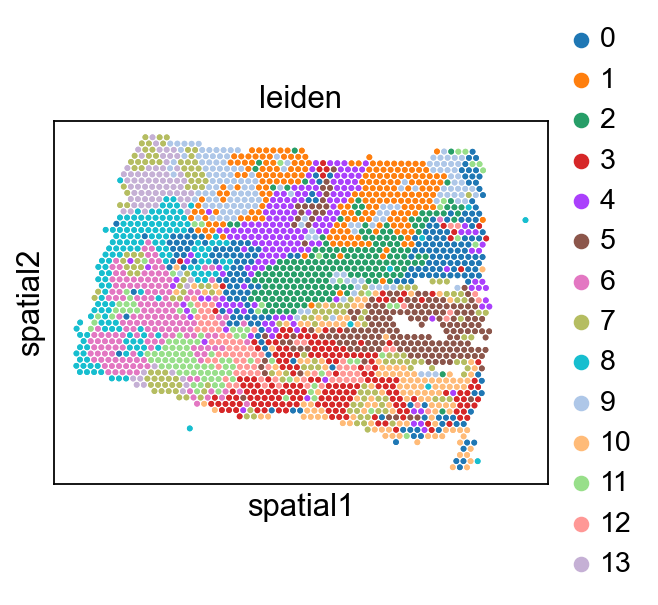

In [25]:
sq.pl.spatial_scatter(pan224_st, shape=None, color="leiden", size=10)

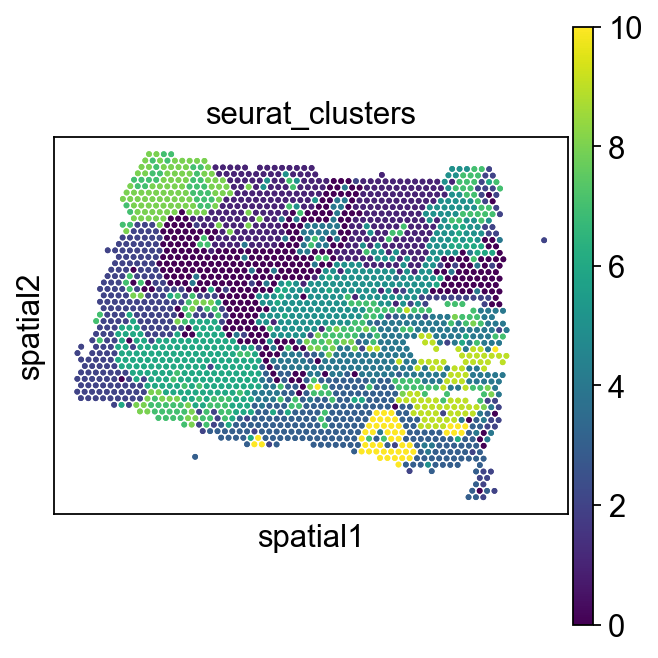

In [26]:
sq.pl.spatial_scatter(pan224_st, shape=None, color="seurat_clusters", size=10)

Creating graph using `generic` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:00)


/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


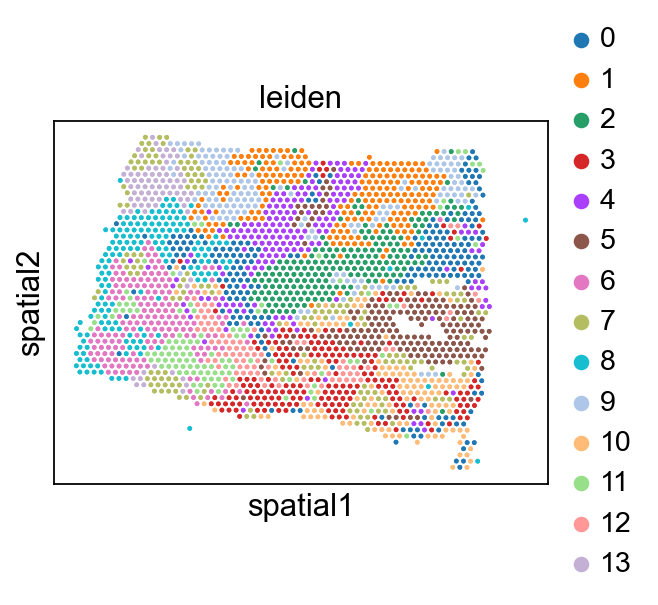

In [27]:
sq.gr.spatial_neighbors(pan224_st, radius=3.0)
sq.pl.spatial_scatter(
    pan224_st,
    color="leiden",
    connectivity_key="spatial_connectivities",
    edges_color="black",
    shape=None,
    edges_width=1,
    size=5,
)

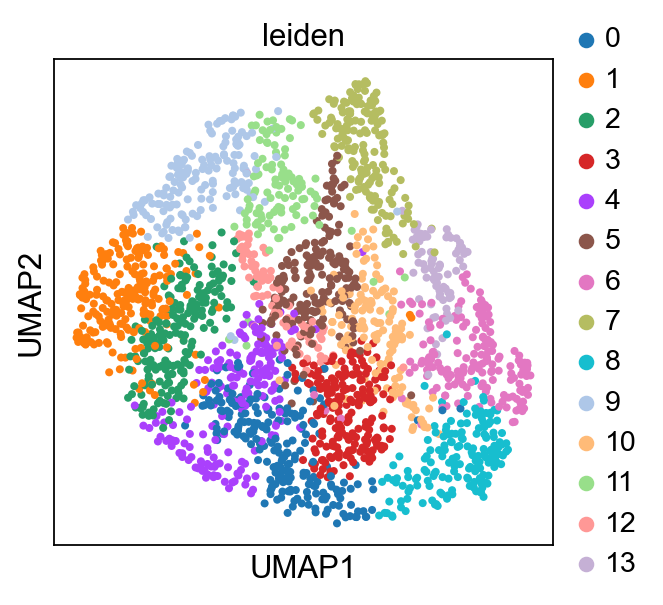

In [28]:
sc.pl.umap(pan224_st, color = "leiden")

Mitochondia-encoded genes (gene names start with prefix mt- or MT-) are irrelevant for spatial mapping because their expression represents technical artifacts in the single cell and nucleus data rather than biological abundance of mitochondria. Yet these genes compose 15-40% of mRNA in each location. Hence, to avoid mapping artifacts we strongly recommend removing mitochondrial genes.

In [29]:
#gènes mitochondriaux
# find mitochondrial (MT) genes
pan224_st.var["MT_gene"] = [
    gene.startswith("MT-") for gene in pan224_st.var["features"]
]

# remove MT genes for spatial mapping (keeping their counts in the object)
pan224_st.obsm["MT"] = pan224_st[:, pan224_st.var["MT_gene"].values].X.toarray()
pan224_st = pan224_st[:, ~pan224_st.var["MT_gene"].values]

In [30]:
shared_features = [
    feature for feature in pan224_st.var_names if feature in pan224_sc.var_names
]
adata_sc = pan224_sc[:, shared_features].copy()
adata_st = pan224_st[:, shared_features].copy()

In [33]:
#configurer et entrainer sur scRNAseq
c2l.models.RegressionModel.setup_anndata(
    adata=adata_sc,
    batch_key="Piece_ID",
    labels_key="cell_type",
)

model = c2l.models.RegressionModel(adata_sc)

model.view_anndata_setup()




/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 0 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(


Anndata setup with scvi-tools version 1.3.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Piece_ID',
│   'labels_key': 'cell_type',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 2798  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  14   │
│          n_vars          │ 36588 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                    batch State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Piece_ID'] │ HT224P1-S1 │          0          │
└───────────────────────┴────────────┴─────────────────────┘

                      labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃   Categories   ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell_type'] │      ADM       │          0          │
│                        │    B-cells     │          1          │
│                        │  Ductal-like1  │          2          │
│                        │  Ductal-like2  │          3          │
│                        │  Endothelial   │          4          │
│                        │  Fibroblasts   │          5          │
│                        │     Islets     │          6          │
│                        │  Low quality   │          7          │
│                        │  Macrophages   │          8          │
│                        │      Mast      │          9          │
│                        │ Other_doublets │         10          │
│                        │     Plasma     │         11          │
│                        │    T-cells     │         12          │
│                        │     Tumor      │         13          │
└────────────────────────┴────────────────┴─────────────────────┘

In [ ]:
model.train(max_epochs=1000, batch_size=2500, train_size=1, lr=0.002)

/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
/opt/anaconda3/envs/ccc/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers w

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
model.save("models/ht224p1_sc_regression", overwrite=True)

In [ ]:
#Pour charger model
model = c2l.models.RegressionModel.load(
    "models/ht224p1_sc_regression",
    adata=adata_sc
)

In [ ]:
model.plot_history(20)

In [ ]:
# Exporter signatures
model.export_posterior(
    adata_sc,
    sample_kwargs={"num_samples": 1000, "batch_size": 2500,},
)

inf_aver = adata_sc.varm['means_per_cluster_mu_fg']  # genes x cell_types
inf_aver.to_csv('signatures_HT224.csv')  # réutilisable

In [ ]:
model.plot_QC()  # diagonal reconstruction

In [ ]:
#modele spatial (deconvolution)
c2l.models.Cell2location.setup_anndata(adata_st)
mod_sp = c2l.models.Cell2location(adata_st, cell_state_df=inf_aver,
                                  N_cells_per_location=8)  # ~8 cellules/spot

mod_sp.train(max_epochs=800)  # plus long, GPU recommandé
mod_sp.plot_history()  # convergence
mod_sp.plot_QC()  # diagonal

# Exporter abondances (q05 = confiance haute)
adata_st = mod_sp.export_posterior(adata_st, 
                                   sample_kwargs={'num_samples':1000})
adata_st.obs[mod_sp.factor_names_] = adata_st.obsm['q05_cell_abundance_w_sf']


In [ ]:
#visualization et validation

sc.pl.spatial(adata_st, color=['T-cells', 'Tumor'], 
              img_key='hires', vmin=0, vmax='p99')
sq.pl.spatial_scatter(adata_st, color='region_cluster')  # après clustering

# Clustering régions tissulaires
sc.pp.neighbors(adata_st, use_rep='q05_cell_abundance_w_sf')
sc.tl.leiden(adata_st)
sc.tl.umap(adata_st)



# Sein : HT425B1